In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import joblib

print("="*60)
print("MODEL BUILDING - BINARY CVD RISK CLASSIFICATION")
print("Classes: 0=INTERMEDIARY, 1=HIGH  (LOW excluded by design)")
print("="*60)

processed_path = '../data/processed/'
df_clean = pd.read_csv(f'{processed_path}processed_data_clean.csv')
print(f"Data shape: {df_clean.shape}")
print(f"Target distribution:")
print(df_clean['CVD_Risk_Encoded'].value_counts().sort_index().rename({0:'INTERMEDIARY',1:'HIGH'}))

feature_cols = [col for col in df_clean.columns if col != 'CVD_Risk_Encoded']
X = df_clean[feature_cols]
y = df_clean['CVD_Risk_Encoded'].astype(int)

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# CV with SMOTE inside pipeline - no data leakage
print("\n" + "="*60)
print("CROSS-VALIDATION WITH SMOTE PIPELINE (no leakage)")
print("="*60)
cv_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb',   XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=42, eval_metric='logloss', verbosity=0))
])
cv_scores = cross_val_score(cv_pipeline, X_train_raw, y_train_raw, cv=5, scoring='accuracy')
print(f'CV scores: {[round(s,4) for s in cv_scores]}')
print(f'CV Mean:   {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')


MODEL BUILDING - BINARY CVD RISK CLASSIFICATION
Classes: 0=INTERMEDIARY, 1=HIGH  (LOW excluded by design)
Data shape: (1309, 33)
Target distribution:
CVD_Risk_Encoded
INTERMEDIARY    581
HIGH            728
Name: count, dtype: int64

CROSS-VALIDATION WITH SMOTE PIPELINE (no leakage)
CV scores: [np.float64(0.7667), np.float64(0.7381), np.float64(0.7703), np.float64(0.756), np.float64(0.756)]
CV Mean:   0.7574 +/- 0.0112


In [2]:
# ============================================
# BLOCK 2: LOAD PROCESSED DATA
# ============================================
print("\n" + "="*60)
print("LOADING PROCESSED DATA")
print("="*60)

processed_path = '../data/processed/'

df_smote = pd.read_csv(f'{processed_path}processed_data_smote.csv')
print(f"SMOTE balanced data shape: {df_smote.shape}")

df_clean = pd.read_csv(f'{processed_path}processed_data_clean.csv')
print(f"Clean data shape: {df_clean.shape}")

print("\nTarget distribution (SMOTE balanced - 0=LOW, 1=INTERMEDIARY, 2=HIGH):")
print(df_smote['CVD_Risk_Encoded'].value_counts().sort_index())

print("\nTarget distribution (Original clean):")
print(df_clean['CVD_Risk_Encoded'].value_counts().sort_index())



LOADING PROCESSED DATA
SMOTE balanced data shape: (1164, 33)
Clean data shape: (1309, 33)

Target distribution (SMOTE balanced - 0=LOW, 1=INTERMEDIARY, 2=HIGH):
CVD_Risk_Encoded
0    582
1    582
Name: count, dtype: int64

Target distribution (Original clean):
CVD_Risk_Encoded
0    581
1    728
Name: count, dtype: int64


In [3]:
# BLOCK 3: PREPARE FEATURES AND TARGET
print('\n' + '='*60)
print('PREPARING FEATURES AND TARGET')
print('='*60)

df = df_clean.copy()
feature_cols = [col for col in df.columns if col != 'CVD_Risk_Encoded']
X = df[feature_cols]
y = df['CVD_Risk_Encoded'].astype(int)

print(f'Features: {X.shape[1]}  |  Rows: {X.shape[0]}')
print(f'Classes:  INTERMEDIARY=0, HIGH=1')

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print(f'\nTrain (pre-SMOTE):  {X_train_raw.shape[0]}  {y_train_raw.value_counts().to_dict()}')
print(f'Train (post-SMOTE): {X_train.shape[0]}  {pd.Series(y_train).value_counts().to_dict()}')
print(f'Test  (real only):  {X_test.shape[0]}  {y_test.value_counts().to_dict()}')
print('NOTE: Test set has NO synthetic samples (correct methodology)')



PREPARING FEATURES AND TARGET
Features: 32  |  Rows: 1309
Classes:  INTERMEDIARY=0, HIGH=1

Train (pre-SMOTE):  1047  {1: 582, 0: 465}
Train (post-SMOTE): 1164  {0: 582, 1: 582}
Test  (real only):  262  {1: 146, 0: 116}
NOTE: Test set has NO synthetic samples (correct methodology)



TRAINING RANDOM FOREST MODEL

Random Forest Performance:
  Accuracy:  0.8053
  Precision: 0.8052
  Recall:    0.8053
  F1-Score:  0.8053
  AUC:       0.8700

Classification Report:
              precision    recall  f1-score   support

INTERMEDIARY       0.78      0.78      0.78       116
        HIGH       0.82      0.83      0.83       146

    accuracy                           0.81       262
   macro avg       0.80      0.80      0.80       262
weighted avg       0.81      0.81      0.81       262



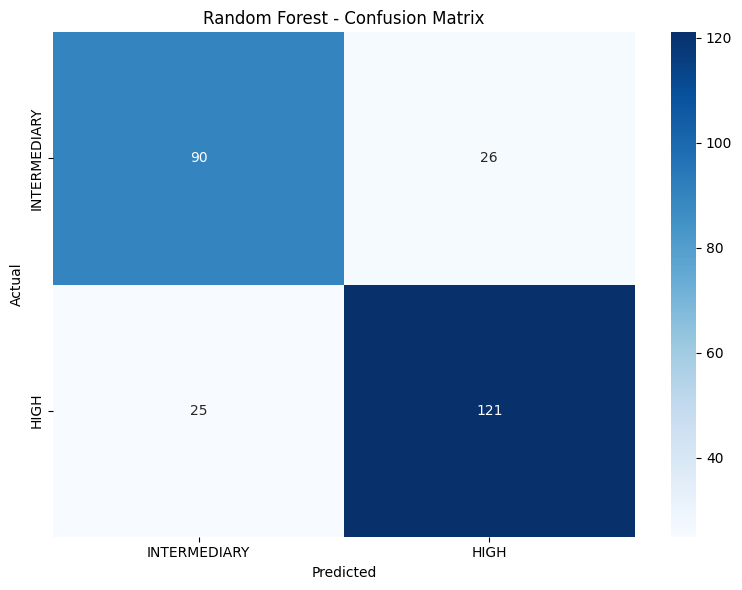

Random Forest model saved.


In [4]:
# BLOCK 4: TRAIN RANDOM FOREST
print("\n" + "="*60)
print("TRAINING RANDOM FOREST MODEL")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    min_samples_split=5, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf   = rf_model.predict(X_test)
y_proba_rf  = rf_model.predict_proba(X_test)[:,1]

accuracy_rf  = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf    = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf        = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
auc_rf       = roc_auc_score(y_test, y_proba_rf)

print(f"\nRandom Forest Performance:")
print(f"  Accuracy:  {accuracy_rf:.4f}")
print(f"  Precision: {precision_rf:.4f}")
print(f"  Recall:    {recall_rf:.4f}")
print(f"  F1-Score:  {f1_rf:.4f}")
print(f"  AUC:       {auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['INTERMEDIARY','HIGH']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['INTERMEDIARY','HIGH'],
            yticklabels=['INTERMEDIARY','HIGH'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.savefig('../images/rf_confusion_matrix.png'); plt.show()

joblib.dump(rf_model, f'{processed_path}random_forest_model.pkl')
print("Random Forest model saved.")



TRAINING XGBOOST MODEL

XGBoost Performance:
  Accuracy:  0.8130
  Precision: 0.8126
  Recall:    0.8130
  F1-Score:  0.8127
  AUC:       0.8997

Classification Report:
              precision    recall  f1-score   support

INTERMEDIARY       0.80      0.78      0.79       116
        HIGH       0.83      0.84      0.83       146

    accuracy                           0.81       262
   macro avg       0.81      0.81      0.81       262
weighted avg       0.81      0.81      0.81       262



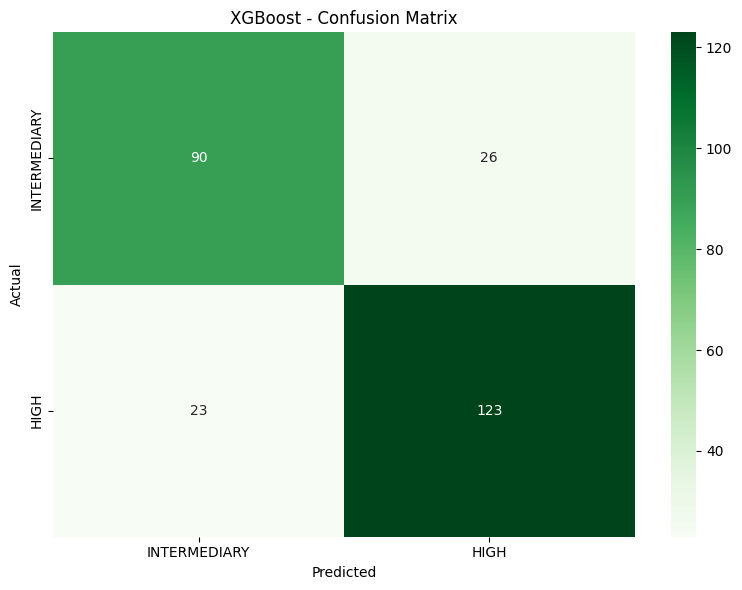

XGBoost model saved.


In [5]:
# BLOCK 5: TRAIN XGBOOST
print("\n" + "="*60)
print("TRAINING XGBOOST MODEL")
print("="*60)

xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

accuracy_xgb  = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
recall_xgb    = recall_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
f1_xgb        = f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
auc_xgb       = roc_auc_score(y_test, y_proba_xgb)

print(f"\nXGBoost Performance:")
print(f"  Accuracy:  {accuracy_xgb:.4f}")
print(f"  Precision: {precision_xgb:.4f}")
print(f"  Recall:    {recall_xgb:.4f}")
print(f"  F1-Score:  {f1_xgb:.4f}")
print(f"  AUC:       {auc_xgb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['INTERMEDIARY','HIGH']))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8,6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['INTERMEDIARY','HIGH'],
            yticklabels=['INTERMEDIARY','HIGH'])
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.savefig('../images/xgb_confusion_matrix.png'); plt.show()

joblib.dump(xgb_model, f'{processed_path}xgboost_model.pkl')
print("XGBoost model saved.")



COMPARING MODELS
   Metric  Random Forest  XGBoost
 Accuracy       0.805344 0.812977
Precision       0.805189 0.812645
   Recall       0.805344 0.812977
 F1-Score       0.805254 0.812703
      AUC       0.870040 0.899681

Best Model (by Accuracy): XGBoost
  Accuracy: 0.8130  (81.30%)
  F1-Score: 0.8127
Best model saved.

Top 10 Features (XGBoost):
                      Feature  Importance
       Smoking Status_Encoded    0.075472
                  Age_Elderly    0.061497
               CVD Risk Score    0.057039
Family History of CVD_Encoded    0.056551
                 Obesity_Risk    0.050679
      Diabetes Status_Encoded    0.044747
    Physical_Activity_Encoded    0.042087
                          Age    0.039503
                   BMI_Normal    0.039086
                    BMI_Obese    0.038921


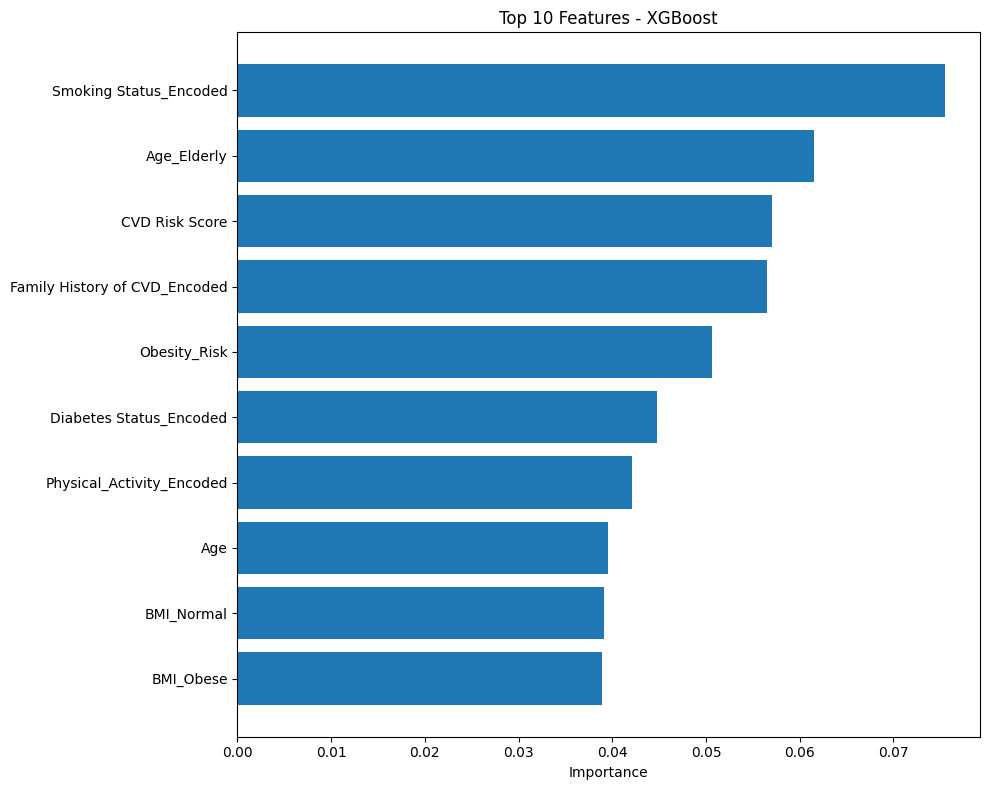

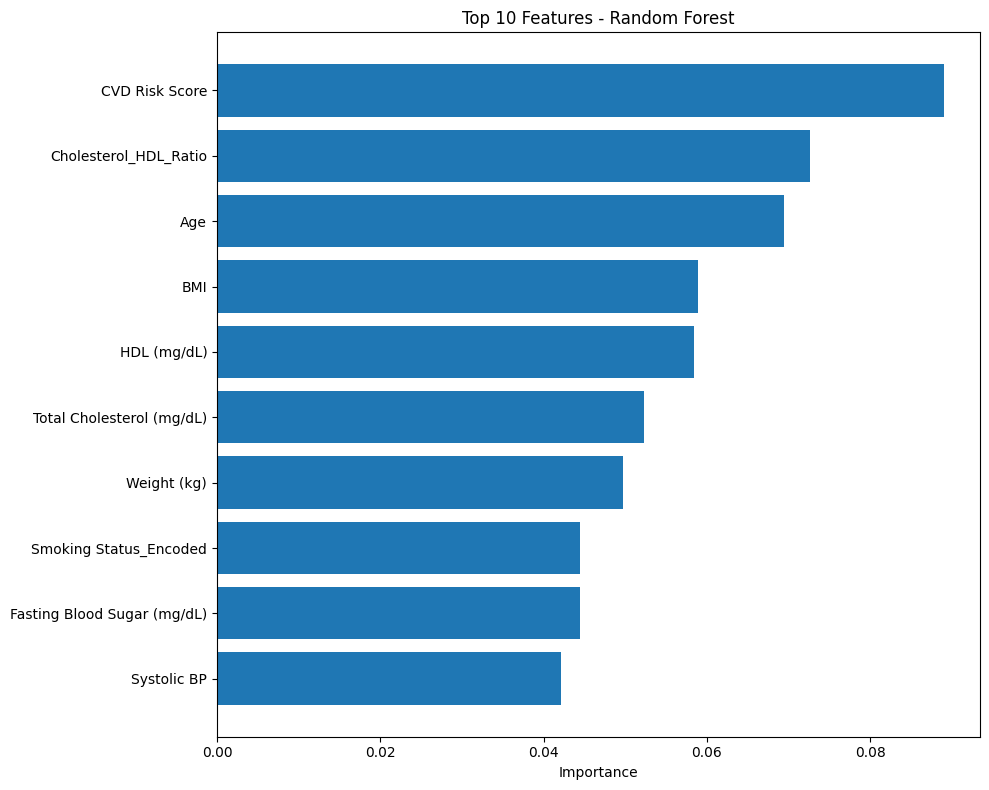

In [6]:
# BLOCK 6: COMPARE MODELS AND FEATURE IMPORTANCE
print("\n" + "="*60)
print("COMPARING MODELS")
print("="*60)

comparison = pd.DataFrame({
    'Metric':         ['Accuracy','Precision','Recall','F1-Score','AUC'],
    'Random Forest':  [accuracy_rf, precision_rf, recall_rf, f1_rf, auc_rf],
    'XGBoost':        [accuracy_xgb, precision_xgb, recall_xgb, f1_xgb, auc_xgb]
})
print(comparison.to_string(index=False))

best_model      = xgb_model if accuracy_xgb >= accuracy_rf else rf_model
best_model_name = 'XGBoost' if accuracy_xgb >= accuracy_rf else 'Random Forest'
best_accuracy   = max(accuracy_xgb, accuracy_rf)
best_f1         = f1_xgb if accuracy_xgb >= accuracy_rf else f1_rf

print(f"\nBest Model (by Accuracy): {best_model_name}")
print(f"  Accuracy: {best_accuracy:.4f}  ({best_accuracy*100:.2f}%)")
print(f"  F1-Score: {best_f1:.4f}")

joblib.dump(best_model, f'{processed_path}best_model.pkl')
print(f"Best model saved.")

# Feature importance
rf_importance = pd.DataFrame({
    'Feature': feature_cols, 'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
xgb_importance = pd.DataFrame({
    'Feature': feature_cols, 'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features (XGBoost):")
print(xgb_importance.head(10).to_string(index=False))

plt.figure(figsize=(10,8))
top = xgb_importance.head(10)
plt.barh(top['Feature'][::-1], top['Importance'][::-1])
plt.title('Top 10 Features - XGBoost'); plt.xlabel('Importance')
plt.tight_layout(); plt.savefig('../images/xgb_feature_importance.png'); plt.show()

plt.figure(figsize=(10,8))
top_rf = rf_importance.head(10)
plt.barh(top_rf['Feature'][::-1], top_rf['Importance'][::-1])
plt.title('Top 10 Features - Random Forest'); plt.xlabel('Importance')
plt.tight_layout(); plt.savefig('../images/rf_feature_importance.png'); plt.show()

xgb_importance.to_csv(f'{processed_path}feature_importance.csv', index=False)


In [7]:
# BLOCK 7: CROSS-VALIDATION ON BEST MODEL (SMOTE inside pipeline)
print("\n" + "="*60)
print("CROSS-VALIDATION ON BEST MODEL (SMOTE inside pipeline)")
print("="*60)

if best_model_name == 'XGBoost':
    cv_model = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                 subsample=0.8, colsample_bytree=0.8,
                                 random_state=42, eval_metric='logloss', verbosity=0))
    ])
else:
    cv_model = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   RandomForestClassifier(n_estimators=100, max_depth=10,
                                          min_samples_split=5, min_samples_leaf=2,
                                          random_state=42, n_jobs=-1))
    ])

cv_scores = cross_val_score(cv_model, X, y, cv=5, scoring='accuracy')
print(f"\nCross-Validation Results ({best_model_name}):")
print(f"  Scores: {[round(s,4) for s in cv_scores]}")
print(f"  Mean:   {cv_scores.mean():.4f}")
print(f"  Std:    {cv_scores.std():.4f}")
print(f"  95% CI: [{cv_scores.mean()-1.96*cv_scores.std():.4f}, {cv_scores.mean()+1.96*cv_scores.std():.4f}]")
print(f"  CV Gap vs Test: {abs(best_accuracy - cv_scores.mean()):.4f}")



CROSS-VALIDATION ON BEST MODEL (SMOTE inside pipeline)

Cross-Validation Results (XGBoost):
  Scores: [np.float64(0.8702), np.float64(0.8969), np.float64(0.8244), np.float64(0.7214), np.float64(0.5287)]
  Mean:   0.7683
  Std:    0.1339
  95% CI: [0.5058, 1.0308]
  CV Gap vs Test: 0.0446


In [8]:
# BLOCK 8: SUMMARY + RISK PROBABILITY DEMO
print("\n" + "="*60)
print("MODEL BUILDING SUMMARY")
print("="*60)

print("\nDataset Information:")
print(f"  Total samples:  {len(df)} (HIGH + INTERMEDIARY only)")
print(f"  LOW excluded:   220 rows (by design - feature overlap too high)")
print(f"  Features:       {len(feature_cols)}")
print(f"  Classes:        INTERMEDIARY=0, HIGH=1")
print(f"  SMOTE:          Applied only to training split")

print("\nModel Performance Summary:")
print(comparison.to_string(index=False))

print(f"\nBest Model:     {best_model_name}")
print(f"  Accuracy:     {best_accuracy:.4f}  ({best_accuracy*100:.2f}%)")
print(f"  F1-Score:     {best_f1:.4f}")
print(f"  CV Mean:      {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# Save results
results_df = pd.DataFrame({
    'Model':    ['Random Forest','XGBoost'],
    'Accuracy': [accuracy_rf, accuracy_xgb],
    'F1_Score': [f1_rf, f1_xgb],
    'AUC':      [auc_rf, auc_xgb],
    'CV_Mean':  [cv_scores.mean(), cv_scores.mean()],
    'CV_Std':   [cv_scores.std(),  cv_scores.std()]
})
results_df.to_csv(f'{processed_path}model_results.csv', index=False)

# Risk probability demo
print("\n" + "="*60)
print("RISK PROBABILITY SCORE DEMO (for real patient)")
print("="*60)
print("Risk label thresholds:")
print("  < 30%  -> LOW RISK          (no immediate concern)")
print("  30-70% -> INTERMEDIARY RISK (monitor closely)")
print("  > 70%  -> HIGH RISK         (immediate intervention)")

sample_patient = X_test.iloc[[0]]
proba = best_model.predict_proba(sample_patient)[0]
risk_pct = proba[1] * 100

# Apply the 3-zone threshold
if risk_pct < 30:
    label = 'LOW RISK'
elif risk_pct <= 70:
    label = 'INTERMEDIARY RISK'
else:
    label = 'HIGH RISK'

print(f"\nExample patient:")
print(f"  INTERMEDIARY probability: {proba[0]*100:.1f}%")
print(f"  HIGH probability:         {proba[1]*100:.1f}%")
print(f"  CVD Risk Score:           {risk_pct:.1f}%")
print(f"  Risk Label:               {label}")
print(f"  Actual label:             {'HIGH' if y_test.iloc[0]==1 else 'INTERMEDIARY'}")

print("\n" + "="*60)
print("MODEL BUILDING COMPLETE")
print("="*60)



MODEL BUILDING SUMMARY

Dataset Information:
  Total samples:  1309 (HIGH + INTERMEDIARY only)
  LOW excluded:   220 rows (by design - feature overlap too high)
  Features:       32
  Classes:        INTERMEDIARY=0, HIGH=1
  SMOTE:          Applied only to training split

Model Performance Summary:
   Metric  Random Forest  XGBoost
 Accuracy       0.805344 0.812977
Precision       0.805189 0.812645
   Recall       0.805344 0.812977
 F1-Score       0.805254 0.812703
      AUC       0.870040 0.899681

Best Model:     XGBoost
  Accuracy:     0.8130  (81.30%)
  F1-Score:     0.8127
  CV Mean:      0.7683 +/- 0.1339

RISK PROBABILITY SCORE DEMO (for real patient)
Risk label thresholds:
  < 30%  -> LOW RISK          (no immediate concern)
  30-70% -> INTERMEDIARY RISK (monitor closely)
  > 70%  -> HIGH RISK         (immediate intervention)

Example patient:
  INTERMEDIARY probability: 2.9%
  HIGH probability:         97.1%
  CVD Risk Score:           97.1%
  Risk Label:               HIGH R